## 오디오파일 로드, 멜 스펙트로그램으로 변환 및 코골이 감지
오디오 파일 로드하고, librosa 라이브러리를 사용하여, 오디오 파형과 스펙트로그램을 시각화. <br>
- sr=None으로 설정: 오디오가 원래 샘플링 레이트로 로드되어서, 오디오 원본 특성 유지 가능.         
- librosa.display.waveshow를 사용하여 오디오의 파형을 시각화하여, 시간에 따른 소리의 크기와 강도를 이해하는데 도움. 

In [ ]:
import os
import matplotlib.pyplot as plt
import librosa
import numpy as np

In [2]:
# file_path = os.path.join(os.getcwd(), "output.wav")
file_path = "C:\\Users\\USER\\Documents\\코골이\\easy_sleep\\data\\raw\\output.wav"


# 오디오 로드
audio, sr = librosa.load(file_path, sr=None)  # 파일의 원래 샘플링 레이트 출력
print(sr)  # 샘플링 레이트

44100


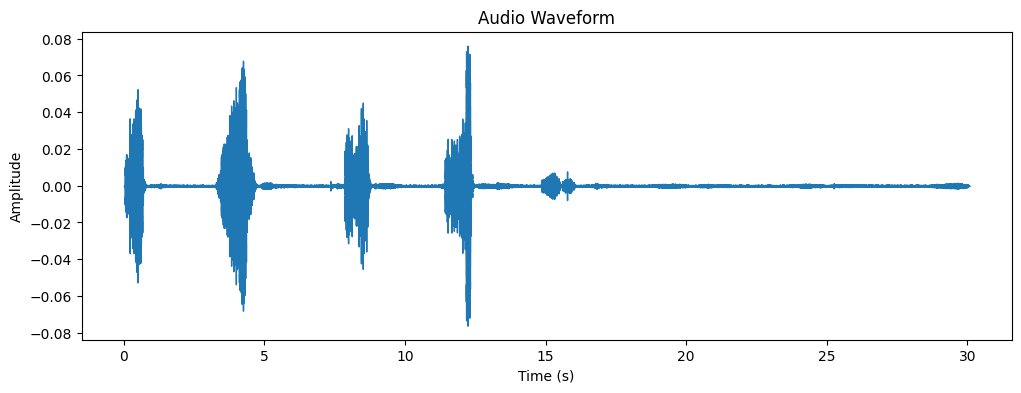

In [3]:
# 파형 시각화

plt.figure(figsize=(12, 4))

librosa.display.waveshow(audio, sr=sr)

plt.title('Audio Waveform')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.show()

- librosa.feature.melspectrogram 함수는 오디오의 멜 스펙트로그램을 계산. 소리를 시간-주파수 형식으로 나타내는 것.
- librosa.power_to_db: 진폭(amplitude) 스펙트로그램을 dB 스케일 스펙트로그램으로 변환
- librosa.display.specshow: y축에 '멜' 스케일과 x축에 시간을 사용. 

In [ ]:
# 멜 스펙트로그램으로 변환
S = librosa.feature.melspectrogram(y=audio, sr=sr)
# 진폭(Amplitude) 스펙트로그램 dB 스케일 스펙트로그램으로 변환
S_DB = librosa.power_to_db(S, ref=np.max)

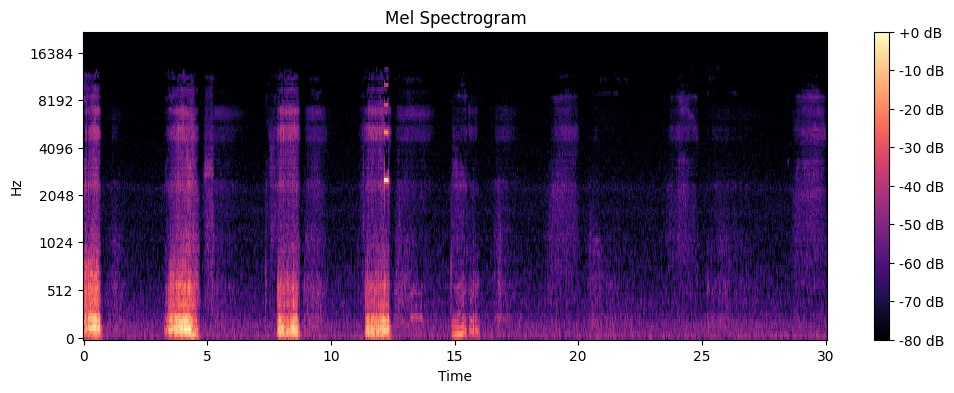

In [5]:
# 스펙트로그램 시각화

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_DB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.show()

In [6]:
# dB값의 최소, 최대, 평균 계산

min_dB = np.min(S_DB)
max_dB = np.max(S_DB)
mean_dB = np.mean(S_DB)

print("Max dB:", max_dB)
print("Min dB:", min_dB)
print("Mean dB:", mean_dB)

Max dB: 0.0
Min dB: -80.0
Mean dB: -69.34288


주파수 대역 분석: 코골이는 특정 주파수 범위에서 더 두드러질 수 있습니다. 

    - 일반적으로 낮은 주파수(예: 100 Hz ~ 1000 Hz)에서 코골이 소리가 더 잘 나타납니다. 
    - 이 범위의 평균 데시벨 수준을 분석하여 코골이 발생을 감지하는 데 사용할 수 있습니다.

In [7]:
# 주파수 범위를 Hz 단위로 지정 (예: 100 Hz ~ 1000 Hz)
freq_min = 200
freq_max = 1100

# 주파수 범위 인덱스 계산
freq_indices = np.where((librosa.mel_frequencies(n_mels=S.shape[0]) >= freq_min) & (
    librosa.mel_frequencies(n_mels=S.shape[0]) <= freq_max))[0]

In [8]:
# 선택된 주파수 범위의 평균 데시벨 계산
target_band_db = np.mean(S_DB[freq_indices, :], axis=0)
print("Average dB in target frequency band:", np.mean(target_band_db))

Average dB in target frequency band: -63.195328


그림을 보면 마지막 패턴은 코골이 같지 않은데, average db 계산시 마지막 패턴도 포함되는거 같음. <br>
    -> 임곗값 조정시, 평균 dB보다 5dB 높게 설정 하는 등의 조치가 필요해보임
<br><br>
멜 스펙트로그램에서 명확하게 높은 에너지를 보이는 부분을 코골이 발생 구간으로 가정 후, 이러한 구간만을 대상으로 평균 dB를 계산

In [10]:
threshold_db = np.mean(target_band_db) + 10  # 평균보다 10dB 높게 설정
print("Threshold dB for snoring detection:", threshold_db)

Threshold dB for snoring detection: -53.19532775878906


In [11]:
snoring_events = target_band_db > threshold_db
times = librosa.frames_to_time(range(len(snoring_events)), sr=sr)
print("Snoring detected at times:", times[snoring_events])

Snoring detected at times: [ 0.02321995  0.03482993  0.04643991  0.05804989  0.06965986  0.08126984
  0.09287982  0.1044898   0.11609977  0.12770975  0.13931973  0.15092971
  0.16253968  0.17414966  0.18575964  0.19736961  0.20897959  0.22058957
  0.23219955  0.24380952  0.2554195   0.26702948  0.27863946  0.29024943
  0.30185941  0.31346939  0.32507937  0.33668934  0.34829932  0.3599093
  0.37151927  0.38312925  0.39473923  0.40634921  0.41795918  0.42956916
  0.44117914  0.45278912  0.46439909  0.47600907  0.48761905  0.49922902
  0.510839    0.52244898  0.53405896  0.54566893  0.55727891  0.56888889
  0.58049887  0.59210884  0.60371882  0.6153288   0.62693878  0.63854875
  0.65015873  0.66176871  0.67337868  3.41333333  3.42494331  3.43655329
  3.44816327  3.45977324  3.47138322  3.4829932   3.49460317  3.50621315
  3.51782313  3.52943311  3.54104308  3.55265306  3.56426304  3.57587302
  3.58748299  3.59909297  3.61070295  3.62231293  3.6339229   3.64553288
  3.65714286  3.66875283 

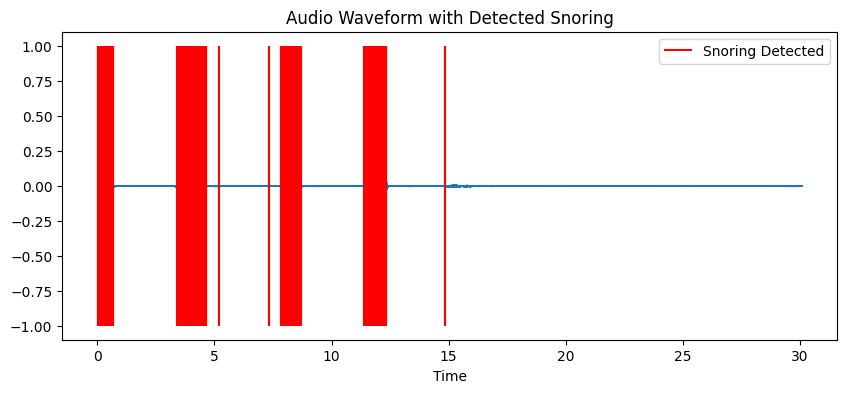

In [12]:
snoring_times = times[snoring_events]
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr)
plt.vlines(snoring_times, ymin=-1, ymax=1, color='r',
           linestyle='-', label='Snoring Detected')
plt.title('Audio Waveform with Detected Snoring')
plt.legend()
plt.show()

## 데시벨 임계값 설정 및 오디오 클리핑

In [13]:
print(S_DB.shape[0]) # 주파수 축
print(S_DB.shape[1]) # 시간 축

128
2591


In [16]:
#  np.mean(S_DB, axis=0)으로 전체 주파수 대역의 평균을 계산하고, 
#  평균값에 +10을 더한 값을 threshold_db(임계값)으로 하여, 임계값보다 큰지 비교하여 인덱스 추출출

snoring_indices = np.mean(S_DB, axis=0) + \
    10 > threshold_db   # 평균 데시벨이 임곗값을 초과하는 지점
print(len(snoring_indices))

2591


In [18]:
snoring_indices[0]  # # Boolean 배열. 시간 프레임수와 동일한 크기를 가져야 합니다.

False

목적: 전반적인 음성 활동 중 코골이 가능성 감지
- 전체 주파수 범위에서의 평균 데시벨 + 10dB가 임계값을 초과하는 시간 인덱스를 찾음
- 모든 주파수를 고려하고 10dB의 여유값을 추가

In [15]:
# 특정 주파수 범위 내에서 임계값을 초과하는 시간 인덱스 찾기
threshold_indices = np.mean(S_DB[freq_indices, :], axis=0) > threshold_db
print(len(threshold_indices))

2591


In [17]:
threshold_indices[0]  # Boolean 배열. 임계값을 넘었는지 못넘었는지 True or False로 처리

False

목적: 코골이 특성 주파수에서의 강한 신호 감지
- 특정 주파수 범위에서의 평균 데시벨이 임계값을 초과하는 시간 인덱스를 찾음
- freq_indices에 해당하는 주파수 대역만 고려 (200~1100 주파수 대역만)

In [20]:
# 임계값을 초과한 시간 프레임의 인덱스
over_threshold_indices = np.where(threshold_indices)[0]
print(over_threshold_indices)

[   2    3    4    5    6    7    8    9   10   11   12   13   14   15
   16   17   18   19   20   21   22   23   24   25   26   27   28   29
   30   31   32   33   34   35   36   37   38   39   40   41   42   43
   44   45   46   47   48   49   50   51   52   53   54   55   56   57
   58  294  295  296  297  298  299  300  301  302  303  304  305  306
  307  308  309  310  311  312  313  314  315  316  317  318  319  320
  321  322  323  324  325  326  327  328  329  330  331  332  333  334
  335  336  337  338  339  340  341  342  343  344  345  346  347  348
  349  350  351  352  353  354  355  356  357  358  359  360  361  362
  363  364  365  366  367  368  369  370  371  372  373  374  375  376
  377  378  379  380  381  382  383  384  385  386  387  388  389  390
  391  392  393  394  395  396  397  398  399  400  401  449  632  633
  675  676  677  678  679  680  681  682  683  684  685  686  687  688
  689  690  691  692  693  694  695  696  697  698  699  700  701  702
  703 

**예시 코드와 상황 설명:**

```python
over_threshold_indices = [2, 3, 4, 10, 11, 12]
current_start = over_threshold_indices[0]  # current_start = 2
```

**첫 번째 반복 (idx = 1)** <br>
`over_threshold_indices[idx] = over_threshold_indices[1] = 3`<br>
`over_threshold_indices[idx-1] = over_threshold_indices[0] = 2`<br>
이 시점에서 `current_start = 2`, 연속된 구간이므로 아무 처리도 하지 않음.<br><br>
**두 번째 반복 (idx = 2)**<br>
`over_threshold_indices[idx] = over_threshold_indices[2] = 4`<br>
`over_threshold_indices[idx-1] = over_threshold_indices[1] = 3`<br>
이 시점에서 `current_start = 2`, 연속된 구간이므로 아무 처리도 하지 않음.<br><br>
**세 번째 반복 (idx = 3)**<br>
`over_threshold_indices[idx] = over_threshold_indices[3] = 10`<br>
`over_threshold_indices[idx-1] = over_threshold_indices[2] = 4`<br>
연속되지 않는 구간이므로 이 시점에서 구간을 처리하게 됩니다<br>
<br>
```python
if (over_threshold_indices[idx-1] - current_start + 1) >= min_segment_length:
    segment_starts.append(current_start)  # segment_starts에 2 추가
    segment_ends.append(over_threshold_indices[idx-1])  # segment_ends에 4 추가
```
<br>
구간은 [2, 3, 4]로 3개 프레임이 되며, 이 구간의 시작점과 끝점이 저장됩니다.
이후 새로운 구간을 시작하기 위해 current_start = 10으로 설정합니다.


**에러 발생 **

```python
---------------------------------------------------------------------------
AttributeError                            Traceback (most recent call last)
Cell In[18], line 22
     20 for i, segment in enumerate(audio_segments):
     21     output_path = f'output_segment_{i}.wav'
---> 22     librosa.output.write_wav(output_path, segment, sr)

File c:\Users\USER\.conda\envs\snoring\lib\site-packages\lazy_loader\__init__.py:94, in attach.<locals>.__getattr__(name)
     92     return attr
     93 else:
---> 94     raise AttributeError(f"No {package_name} attribute {name}")

AttributeError: No librosa attribute output
```


Librosa 버전 0.8.0 이후로 librosa.output.write_wav 함수는 제거되었고, 대신 soundfile 라이브러리를 사용하여 오디오 파일을 쓰는 것이 권장

In [ ]:
# %pip install soundfile
import soundfile as sf

In [23]:
min_segment_length = 1.0  # 최소 세그먼트 길이 (초)
audio_segments = []

if len(over_threshold_indices) > 0:  # 임계값을 넘은 시간 프레임의 인덱스 리스트가 0보다 크면,

    segment_starts = [over_threshold_indices[0]] # 시작 인덱스 초기화
    segment_ends = []

     # 반복문 속에서 연속구간 찾기
    for idx in range(1, len(over_threshold_indices)): 

        # 연속된 인덱스 판단하는 조건문으로, 연속되지 않을 경우 
        # 인덱스와 그 인덱스에서 -1 뺀 후 +1이 같은 값이 아닐경우 -> 이부분 np.diff로 처리가능
        if over_threshold_indices[idx] != over_threshold_indices[idx-1] + 1:
            # 연속되지 않은 구간이 발생하면, 그 전까지의 구간을 저장 및 길이 구하기
            segment_ends.append(over_threshold_indices[idx-1])

            if idx < len(over_threshold_indices) - 1: 
                segment_starts.append(over_threshold_indices[idx])

    # 마지막 인덱스 처리

    segment_ends.append(over_threshold_indices[-1])  


    # 오디오의 해당 구간을 잘라내기
    for start, end in zip(segment_starts, segment_ends):
        # 프레임길이를 초로 변환한 후 비교, 왜냐하면 min_segment_length가 초 단위이기 때문문
        duration_sec = librosa.frames_to_time(end + 1, sr=sr, hop_length=512) \
            - librosa.frames_to_time(start,sr=sr, hop_length=512)

        if end - start + 1> min_segment_length: 
            start_sample = librosa.frames_to_samples(start, hop_length=512)
            end_sample = librosa.frames_to_samples(end + 1)  # 마지막 프레임 포함
            audio_segments.append(audio[start_sample:end_sample])

# 오디오 세그먼트 확인 또는 저장
for i, segment in enumerate(audio_segments):
    output_path = f'out_segment_{i}.wav'
    sf.write(output_path, segment, sr)  # 각 세그먼트를 파일로 저장

    # 파일 길이 확인
    duration = librosa.get_duration(path=output_path)
    if duration < 0.5:
        os.remove(output_path)  # 1초 미만이면 파일 삭제
        print(
            f"Deleted {output_path} due to insufficient duration ({duration} sec).")
    else:
        print(f"Saved {output_path} with duration {duration} sec.")

Saved out_segment_0.wav with duration 0.6617687074829932 sec.
Saved out_segment_1.wav with duration 1.253877551020408 sec.
Deleted out_segment_2.wav due to insufficient duration (0.023219954648526078 sec).
Saved out_segment_3.wav with duration 0.8707482993197279 sec.
Saved out_segment_4.wav with duration 0.9520181405895691 sec.
Deleted out_segment_5.wav due to insufficient duration (0.023219954648526078 sec).


In [ ]:
def extract_snoring_segments(over_threshold_indices, audio, min_duration_sec=1.0):
    """
    임계값을 넘은 연속 구간들을 찾아서 오디오 세그먼트로 추출
    
    Parameters:
    - over_threshold_indices: 임계값을 넘은 프레임 인덱스들
    - audio: 원본 오디오 데이터
    - sr: 샘플링 레이트
    - min_duration_sec: 최소 세그먼트 길이 (초)
    
    Returns:
    - audio_segments: 추출된 오디오 세그먼트 리스트
    """
    audio_segments = []

    diff = np.diff(over_threshold_indices) > 1  # 차이가 1보다 크면
    split_points = np.where(diff)[0] + 1 # 연속성이 끊어지는 지점 

    # 연속 구간들 
    continuous_segments = np.split(over_threshold_indices, split_points)

    for i, segment in enumerate(continuous_segments):
        if len(segment) < 2: # 2초 이하의 너무 짧은 구간은 건너뛰기 (드르렁 기준) 
            continue
        
        start_frame = segment[0]
        end_frame = segment[-1]
        
        # 프레임 인덱스를, 오디오 샘플 인덱스로 변환
        start = librosa.frames_to_samples(start_frame, hop_length=512)
        end = librosa.frames_to_samples(end_frame + 1, hop_length=512)
        # 오디오 세그먼트 추출
        audio_segment = audio[start:end]

        # 길이 확인 (초 단위)
        duration_sec = end - start

        if duration_sec >= min_duration_sec:
            audio_segments.append(audio_segment)
            print(f"세그먼트 {i}: {duration_sec:.2f}초. audio_segments에 저장")
        else:
            print(f"세그먼트 {i}: 1초 혹은 그보다 짧음. {duration_sec:.2f}초.")

    return audio_segments
    

In [36]:
audio_segments = extract_snoring_segments(over_threshold_indices, audio)

세그먼트 0: 29184.00초. audio_segments에 저장
세그먼트 1: 55296.00초. audio_segments에 저장
세그먼트 3: 1024.00초. audio_segments에 저장
세그먼트 4: 38400.00초. audio_segments에 저장
세그먼트 5: 41984.00초. audio_segments에 저장
세그먼트 6: 1024.00초. audio_segments에 저장


In [51]:
def save_segment_audio(audio_segments, sr, min_duration=0.5, output_dir=''):

    from pathlib import Path

    # 현재 디렉토리에서 상위로 올라가서 다른 폴더로 이동
    output_dir = Path('../data/processed/')    

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    else:
        pass
    
    print(f"Saving to directory: {output_dir.resolve()}")  # 절대 경로 출력

    saved_count = 0

    # 오디오 세그먼트 확인 또는 저장
    for i, segment in enumerate(audio_segments):
        output_path = os.path.join(output_dir, f'output_segment{i}.wav')
        sf.write(output_path, segment, sr)  # 각 세그먼트를 파일로 저장

        # 파일 길이 확인
        duration = librosa.get_duration(path=output_path)
        if duration < min_duration:
            os.remove(output_path)  # 0.5초 미만이면 파일 삭제
            print(
                f"삭제 Deleted {output_path} due to insufficient duration ({duration} sec).")
        else:
            saved_count += 1
            print(f"저장 Saved {output_path} with duration {duration} sec.")
        
    print(f"총 {saved_count}개 세그먼트 파일 저장")

In [41]:
os.getcwd()

'c:\\Users\\USER\\Documents\\코골이\\easy_sleep\\notebooks'

In [52]:
save_segment_audio(audio_segments, sr)

Saving to directory: C:\Users\USER\Documents\코골이\easy_sleep\data\processed
저장 Saved ..\data\processed\output_segment0.wav with duration 0.6617687074829932 sec.
저장 Saved ..\data\processed\output_segment1.wav with duration 1.253877551020408 sec.
삭제 Deleted ..\data\processed\output_segment2.wav due to insufficient duration (0.023219954648526078 sec).
저장 Saved ..\data\processed\output_segment3.wav with duration 0.8707482993197279 sec.
저장 Saved ..\data\processed\output_segment4.wav with duration 0.9520181405895691 sec.
삭제 Deleted ..\data\processed\output_segment5.wav due to insufficient duration (0.023219954648526078 sec).
총 4개 세그먼트 파일 저장
